### Pseudo-OHLC Data Generation

We can generate synthetic OHLC chart and use this fake chart to train our model

### Here a real chart of BTCUSDT at random hour

In [ ]:
import pandas as pd
from dataWorker import *

start,end,duration,df = getRandomIntervalData('BTCUSDT',127, normalize=True)

df.to_parquet(f"data/real/btcusdt_{duration}_{start}_{end}.parquet", index=False)

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


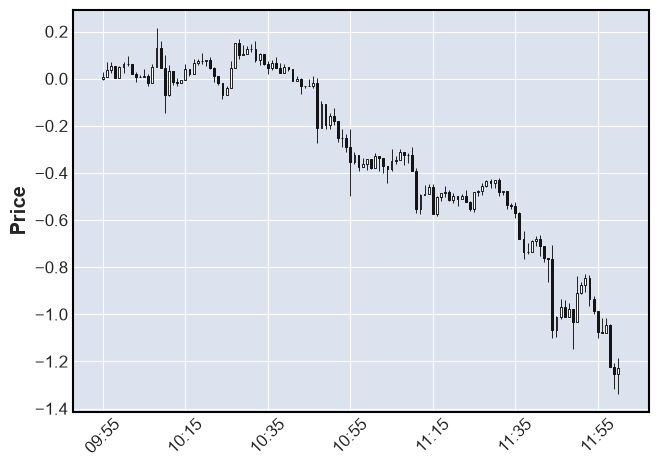

In [2]:
import mplfinance as mpf

#index
df = df.set_index("timestamp")
# plotting
mpf.plot(df, type='candle')


### Here we generate synthetic chart

Using _**Gaussian Distribution**_ for candle body generation and _**Student's t-distribution**_ for wick is best way to generate synthetic chart

In [3]:
from generator import generateSyntheticChart

df, seed = generateSyntheticChart(125)

Seed: 3104751


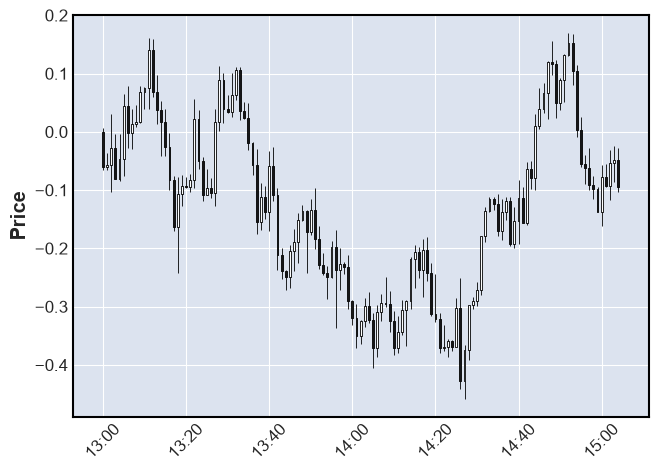

In [4]:
import pandas as pd
import mplfinance as mpf

df["timestamp"] = pd.to_datetime(df["timestamp"].astype("int64"), unit="ms")
#index
df = df.set_index("timestamp")
# plotting
print(f"Seed: {seed}")
mpf.plot(df, type='candle')

In [8]:
from generator import generateSyntheticChart, saveDataSet
import pandas as pd
from tqdm import tqdm

qty = 10000

dtset = []
for i in tqdm(range(qty)):
    df,seed = generateSyntheticChart( 127 )
    
    dtset.append([df, seed])
    
print(f"Generated {len(dtset)} charts")
saveDataSet(dtset, 'data/synthetic/0046_002_4_5')

100%|██████████| 10000/10000 [00:05<00:00, 1922.89it/s]


Generated 10000 charts
